### Ejercicio: Red Neuronal para convertir grados Celsius a Fahrenheit

En este ejercicio vamos a construir una red neuronal simple para convertir grados Celsius a Fahrenheit. Sabemos que la fórmula de conversión es:

$$Fahrenheit = (Celsius \times 1.8) + 32$$

El modelo de red neuronal (RNA) tomará los grados Celsius como entrada, multiplicará por un peso de la conexión (que aprenderá durante el entrenamiento) y sumará un sesgo para generar el valor de Fahrenheit.

El objetivo es entrenar una red neuronal para que aprenda esta conversión.

Resultado = (GradosCelsius * Peso) + Sesgo

[Calculadora de grados](https://www.digikey.com/es/resources/conversion-calculators/conversion-calculator-temperature)

![imagen](https://i.ytimg.com/vi/H3q6Wm0nTZ4/maxresdefault.jpg)

##Importación de bibliotecas

In [1]:
# Importamos las bibliotecas necesarias
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [2]:
!python --version

Python 3.12.12


In [3]:
print(tf.__version__)

2.19.0


##Generación de datos de entrenamiento

In [4]:
celsius = np.array([-35,-30, -20,-10, -5, 0, 10, 15, 20, 25, 35,40], dtype=float)
fahrenheit = celsius * 1.8 + 32
fahrenheit

array([-31., -22.,  -4.,  14.,  23.,  32.,  50.,  59.,  68.,  77.,  95.,
       104.])

In [5]:
celsius, fahrenheit

(array([-35., -30., -20., -10.,  -5.,   0.,  10.,  15.,  20.,  25.,  35.,
         40.]),
 array([-31., -22.,  -4.,  14.,  23.,  32.,  50.,  59.,  68.,  77.,  95.,
        104.]))

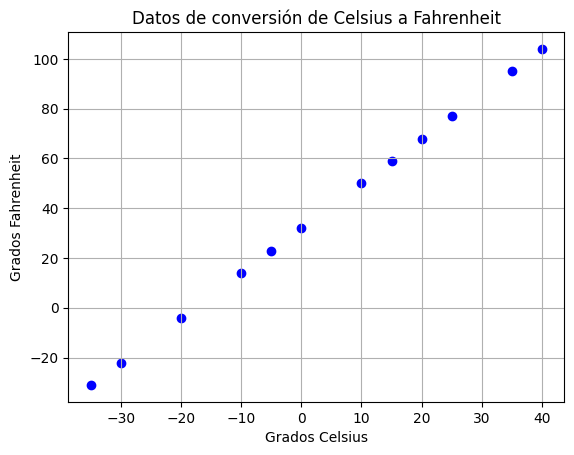

In [6]:
# Visualizamos los datos de entrada y salida
plt.scatter(celsius, fahrenheit, color='blue')
plt.title('Datos de conversión de Celsius a Fahrenheit')
plt.xlabel('Grados Celsius')
plt.ylabel('Grados Fahrenheit')
plt.grid(True)
plt.show()

#Preprocesamiento de los datos

**No es necesario preprocesar los datos en este caso, ya que son simples valores numéricos calculados por fórmula.**
Pero, si fuera necesario, podríamos escalar los datos para mejorar el entrenamiento.

Para este ejemplo, simplemente vamos a proceder con los valores tal como están.


#Creación del modelo de red neuronal

* Para aplicar redes neuronales, vamos a utilizar la librería Keras, que nos facilita el desarrollo de modelos de redes neuronales de manera sencilla. En este caso, vamos a crear una variable llamada layer de tipo Layer en Keras. Las capas densas son aquellas en las que cada neurona está conectada con todas las neuronas de la siguiente capa. En este modelo, tenemos dos capas: una con una neurona de entrada y otra con una neurona de salida. Al definir la capa, pasamos como parámetro units, que representa el número de neuronas en la capa de salida (en este caso, 1). Además, usamos el parámetro input_shape con valor 1, ya que tenemos una sola neurona de entrada.

* A continuación, creamos una variable llamada model de tipo Sequential en Keras para agrupar y organizar las capas. El modelo Sequential es el más sencillo y se utiliza para redes neuronales en las que las capas se apilan una sobre otra de forma lineal. Para redes más complejas, existen otros tipos de modelos.

* Después de definir el modelo, es necesario compilarlo para que pueda ser entrenado. Para ello, se pasan dos parámetros:

* **optimizer**: Aquí usamos el algoritmo Adam, que ayuda a que la red neuronal aprenda de manera eficiente, ajustando los pesos y sesgos para mejorar la predicción con cada iteración. La tasa de aprendizaje (learning rate) es un valor clave que determina qué tan grande es el ajuste de los pesos y sesgos en cada paso. En general, la tasa de aprendizaje se elige mediante prueba y error, pero un buen punto de partida es un valor pequeño, como 0.1 o 0.01. Si el valor es muy pequeño, el ajuste será muy lento; si es muy grande, la red puede no converger correctamente y no aprender bien.

* **loss function**: Usamos la función de pérdida mean_squared_error (error cuadrático medio). Esta función penaliza los errores grandes de manera más severa que los pequeños, lo que significa que una pequeña cantidad de errores grandes es peor que muchos errores pequeños.


In [7]:
from tensorflow.keras.layers import Input

# Creamos el modelo de red neuronal con Input() como la capa de entrada
optmizador = tf.keras.optimizers.Adam(learning_rate=0.01)
model = tf.keras.Sequential([
    Input(shape=(1,)),  # Define la forma de entrada como un solo valor
    tf.keras.layers.Dense(1)  # Capa densa con 1 neurona de salida
])

# Compilamos el modelo con el optimizador 'adam' y la función de pérdida 'mean_squared_error'
model.compile(optimizer=optmizador, loss='mean_squared_error')

#Pruebe modificando el optimzador, solo poner optimizer='adam'

In [8]:

#?COMO ADICIONAR MAS CAPAS PARA MEJORAR EL PERFORMANCE?
from tensorflow.keras.layers import Input

# Creamos el modelo de red neuronal con Input() como la capa de entrada
optmizador = tf.keras.optimizers.Adam(learning_rate=0.01)
model = tf.keras.Sequential([
    Input(shape=(1,)),  # Define la forma de entrada como un solo valor
    tf.keras.layers.Dense(30, activation='relu'), # Primera capa oculta con 30 neuronas, cambia y prueba otras funciones de activación
    tf.keras.layers.Dense(15, activation='relu'), # Segunda capa oculta con 15 neuronas, cambia y prueba otras funciones de activación
    tf.keras.layers.Dense(1)  # Capa densa con 1 neurona de salida
])

# Compilamos el modelo con el optimizador 'adam' y la función de pérdida 'mean_squared_error'
model.compile(optimizer=optmizador, loss='mean_squared_error')

#Pruebe modificando el optimzador, solo poner optimizer='adam'

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 30)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541 (2.11 KB)

 Trainable params: 541 (2.11 KB)

 Non-trainable params: 0 (0.00 B)

#Entrenamiento del modelo
Luego creamos el historial, le pasamos la lista de entrada y de salida, las vueltas (iteraciones) y verbose=false para que no imprima cosas que no necesitamos

In [ ]:
print("Comienza entrenamiento..")
history = model.fit(celsius, fahrenheit, epochs=1000, verbose=True)
print("Modelo entrenado!")

#Pruebe poniendo verbose=False, menos epochs.

Comienza entrenamiento..
Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 2958.1658
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 2668.6074
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 2385.5239
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 2085.0247
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1795.3909
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1519.2681
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 1247.3152
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 996.4264
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 781.7999
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 610.7421
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 470.3671
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 361.0068
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 289.0840
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 257.5630
Epoch 15/1

#Visualizar la función de pérdida

Después, usamos matplotlib para poder graficar el comportamiento de aprendizaje de la red en base a las vueltas y las capas. Podemos observar que la red necesitó unas 400 vueltas aprox para encontrar el algoritmo óptimo para el problema.

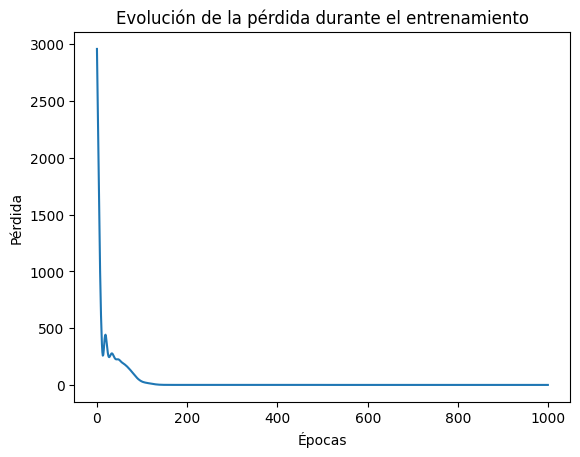

In [ ]:
# Visualizamos la evolución de la pérdida durante el entrenamiento
plt.plot(history.history['loss'])
plt.title('Evolución de la pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.show()

In [ ]:
print("Prección 1")
result = model.predict(np.array([80]))
print("El resultado es" + str(result) + " fahrenheit.")

Prección 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
El resultado es[[196.10277]] fahrenheit.


#Evaluar gráficamente el modelo con los datos reales

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


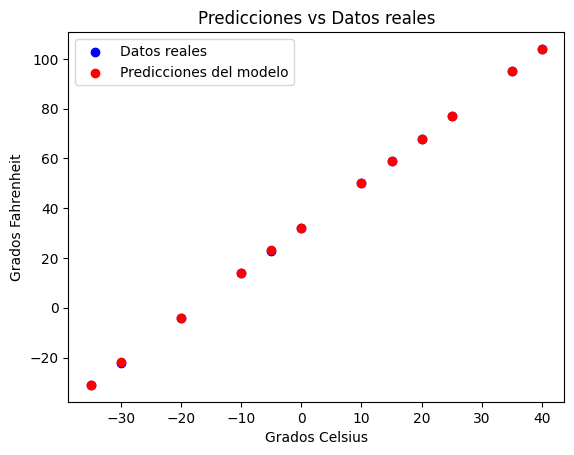

In [ ]:
# Evaluamos el modelo con los mismos datos de entrada para ver el rendimiento
predicciones = model.predict(celsius)

# Visualizamos las predicciones junto con los datos reales
plt.scatter(celsius, fahrenheit, color='blue', label='Datos reales')
plt.scatter(celsius, predicciones, color='red', label='Predicciones del modelo')
plt.title('Predicciones vs Datos reales')
plt.xlabel('Grados Celsius')
plt.ylabel('Grados Fahrenheit')
plt.legend()
plt.show()
